# GLD

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, skew
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Path to the GLD data file
file_path = "GLD.us.txt"

# Load the file
df = pd.read_csv(file_path, delimiter=',')

In [3]:
# Display general information about the data
print("General information about the data: ")
df.info()

# Show the first few rows of the dataset
print("\nFirst few rows of the data: ")
df.head()

General information about the data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3201 entries, 0 to 3200
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3201 non-null   object 
 1   Open     3201 non-null   float64
 2   High     3201 non-null   float64
 3   Low      3201 non-null   float64
 4   Close    3201 non-null   float64
 5   Volume   3201 non-null   int64  
 6   OpenInt  3201 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 175.2+ KB

First few rows of the data: 


,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,43.41,43.55,43.22,43.50,1100100,0
1,2005-02-28,43.68,43.74,43.52,43.52,759100,0
2,2005-03-01,43.30,43.37,43.10,43.22,3245500,0
3,2005-03-02,43.16,43.35,43.08,43.25,1188000,0
4,2005-03-03,43.06,43.13,42.90,42.97,1924600,0


In [4]:
# check null value 
null_count = df.isnull().sum()

null_count_sum = df.isnull().sum().sum()
print('Number of null values:', null_count_sum)

print("\nAmount of null values in each column:")
print(null_count)

Number of null values: 0

Amount of null values in each column:
Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64


#### Columns Information

In [5]:
# column information: Open
Open_unique = df['Open'].unique()
print(f"Open_unique: {Open_unique} \n")

count = Open_unique.size
print(f"Get the count of unique values in a column Open: {count}\n")

# the third one is null
print("The value count:", df['Open'].value_counts())

# min & max value
print("Min value:", df['Open'].min())
print("Max value:", df['Open'].max())

Open_unique: [ 43.41  43.68  43.3  ... 120.82 121.36 121.95] 

Get the count of unique values in a column Open: 2699

The value count: Open
119.00    6
118.86    4
109.16    4
42.45     4
42.33     4
         ..
91.54     1
92.35     1
94.25     1
92.95     1
121.95    1
Name: count, Length: 2699, dtype: int64
Min value: 41.41
Max value: 184.58


In [6]:
# column information: High
High_unique = df['High'].unique()
print(f"High_unique: {High_unique} \n")

count = High_unique.size
print(f"Get the count of unique values in a column High: {count}\n")

# the third one is null
print("The value count:", df['High'].value_counts())

# min & max value
print("Min value:", df['High'].min())
print("Max value:", df['High'].max())

High_unique: [ 43.55  43.74  43.37 ... 121.85 121.31 122.25] 

Get the count of unique values in a column High: 2711

The value count: High
92.00     4
42.48     4
42.56     4
121.59    4
115.79    4
         ..
92.50     1
92.23     1
90.64     1
91.03     1
122.25    1
Name: count, Length: 2711, dtype: int64
Min value: 41.65
Max value: 185.85


In [7]:
# column information: Low
Low_unique = df['Low'].unique()
print(f"Low_unique: {Low_unique} \n")

count = Low_unique.size
print(f"Get the count of unique values in a column Low: {count}\n")

# the third one is null
print("The value count:", df['Low'].value_counts())

# min & max value
print("Min value:", df['Low'].min())
print("Max value:", df['Low'].max())

Low_unique: [ 43.22   43.52   43.1   ... 120.93  121.59  120.935] 

Get the count of unique values in a column Low: 2737

The value count: Low
122.030    5
121.730    5
121.550    4
117.500    4
108.460    4
          ..
90.150     1
91.300     1
91.580     1
90.130     1
120.935    1
Name: count, Length: 2737, dtype: int64
Min value: 41.33
Max value: 182.1


In [8]:
# column information: Close
Close_unique = df['Close'].unique()
print(f"Close_unique: {Close_unique} \n")

count = Close_unique.size
print(f"Get the count of unique values in a column Close: {count}\n")

# the third one is null
print("The value count:", df['Close'].value_counts())

# min & max value
print("Min value:", df['Close'].min())
print("Max value:", df['Close'].max())

Close_unique: [ 43.5   43.52  43.22 ... 120.67 121.21 121.63] 

Get the count of unique values in a column Close: 2714

The value count: Close
115.94    5
92.29     4
117.96    4
87.42     4
122.21    4
         ..
93.41     1
92.11     1
91.20     1
91.62     1
121.63    1
Name: count, Length: 2714, dtype: int64
Min value: 41.53
Max value: 184.59


In [9]:
# column information: Volume
Volume_unique = df['Volume'].unique()
print(f"Volume_unique: {Volume_unique} \n")

count = Volume_unique.size
print(f"Get the count of unique values in a column Volume: {count}\n")

# the third one is null
print("The value count:", df['Volume'].value_counts())

# min & max value
print("Min value:", df['Volume'].min())
print("Max value:", df['Volume'].max())

Volume_unique: [1100100  759100 3245500 ... 5564212 6072394 7100175] 

Get the count of unique values in a column Volume: 3199

The value count: Volume
3201000     2
2979300     2
11253824    1
7337840     1
8705157     1
           ..
18139774    1
17923782    1
14536031    1
18208139    1
7100175     1
Name: count, Length: 3199, dtype: int64
Min value: 319300
Max value: 93783775


In [10]:
# column information: OpenInt
OpenInt_unique = df['OpenInt'].unique()
print(f"OpenInt_unique: {OpenInt_unique} \n")

count = OpenInt_unique.size
print(f"Get the count of unique values in a column OpenInt: {count}\n")

# the third one is null
print("The value count:", df['OpenInt'].value_counts())

# min & max value
print("Min value:", df['OpenInt'].min())
print("Max value:", df['OpenInt'].max())

OpenInt_unique: [0] 

Get the count of unique values in a column OpenInt: 1

The value count: OpenInt
0    3201
Name: count, dtype: int64
Min value: 0
Max value: 0


In [11]:
# column information: Date
Date_unique = df['Date'].unique()
print(f"Date_unique: {Date_unique} \n")

count = Date_unique.size
print(f"Get the count of unique values in a column Date: {count}\n")

# the third one is null
print("The value count:", df['Date'].value_counts())

# min & max value
print("Min value:", df['Date'].min())
print("Max value:", df['Date'].max())

Date_unique: ['2005-02-25' '2005-02-28' '2005-03-01' ... '2017-11-08' '2017-11-09'
 '2017-11-10'] 

Get the count of unique values in a column Date: 3201

The value count: Date
2005-02-25    1
2013-08-26    1
2013-08-12    1
2013-08-13    1
2013-08-14    1
             ..
2009-05-28    1
2009-05-29    1
2009-06-01    1
2009-06-02    1
2017-11-10    1
Name: count, Length: 3201, dtype: int64
Min value: 2005-02-25
Max value: 2017-11-10


# Data Cleaning

#### Removing OpenInt column

In [12]:
df = df.drop(['OpenInt'], axis=1)

df.head()

,Date,Open,High,Low,Close,Volume
0,2005-02-25,43.41,43.55,43.22,43.50,1100100
1,2005-02-28,43.68,43.74,43.52,43.52,759100
2,2005-03-01,43.30,43.37,43.10,43.22,3245500
3,2005-03-02,43.16,43.35,43.08,43.25,1188000
4,2005-03-03,43.06,43.13,42.90,42.97,1924600


the OpenInt data were all 0s, and they do not have any effection on the analysis

#### Formatting date column

In [13]:
# Check the Date column
print(df['Date'].head(10))

# Convert the Date column to datetime with a specified format
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = df[df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
df = df.dropna(subset=['Date'])

# Recheck the data information
print(df.info())
df

0    2005-02-25
1    2005-02-28
2    2005-03-01
3    2005-03-02
4    2005-03-03
5    2005-03-04
6    2005-03-07
7    2005-03-08
8    2005-03-09
9    2005-03-10
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3201 entries, 0 to 3200
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3201 non-null   datetime64[ns]
 1   Open    3201 non-null   float64       
 2   High    3201 non-null   float64       
 3   Low     3201 non-null   float64       
 4   Close   3201 non-null   float64       
 5   Volume  3201 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 150.2 KB
None


,Date,Open,High,Low,Close,Volume
0,2005-02-25,43.41,43.55,43.220,43.50,1100100
1,2005-02-28,43.68,43.74,43.520,43.52,759100
2,2005-03-01,43.30,43.37,43.100,43.22,3245500
3,2005-03-02,43.16,43.35,43.080,43.25,1188000
4,2005-03-03,43.06,43.13,42.900,42.97,1924600
...,...,...,...,...,...,...
3196,2017-11-06,120.72,121.85,120.680,121.65,6952387
3197,2017-11-07,121.15,121.31,120.930,121.21,4164336
3198,2017-11-08,121.95,122.25,121.590,121.63,5564212
3199,2017-11-09,121.85,122.41,121.730,122.13,6072394


#### Recognizing the outliers

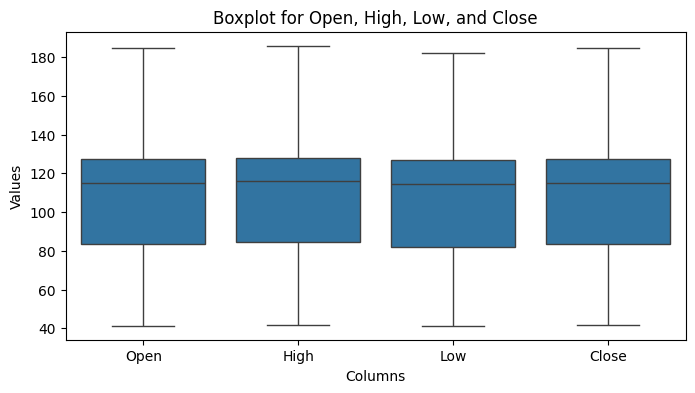

In [14]:
# Prepare the data for grouped plotting
columns_to_plot = ['Open', 'High', 'Low', 'Close']
melted_data = df[columns_to_plot].melt(var_name="Columns", value_name="Values")

# Plot the boxplot for all columns in one figure
plt.figure(figsize=(8, 4))
sns.boxplot(data=melted_data, x="Columns", y="Values")
plt.title("Boxplot for Open, High, Low, and Close")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()


The boxplot shows the distribution of "Open," "High," "Low," and "Close" values. The data appears to be symmetrically distributed, with no significant outliers in any of the columns. The interquartile range (IQR) and median values are consistent across the columns, indicating uniformity in the dataset.

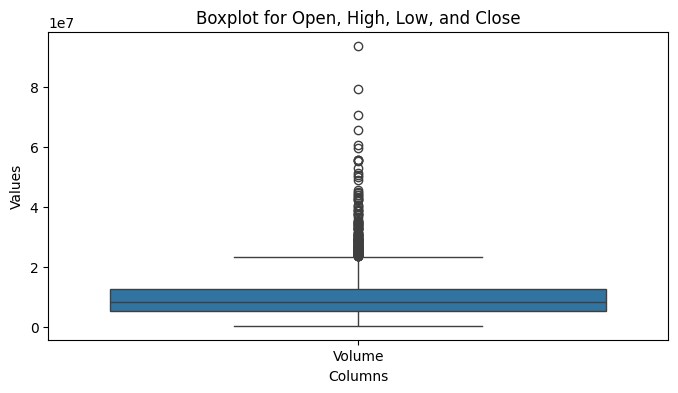

In [15]:
# Prepare the data for grouped plotting
columns_to_plot = ['Volume']
melted_data = df[columns_to_plot].melt(var_name="Columns", value_name="Values")

# Plot the boxplot for all columns in one figure
plt.figure(figsize=(8, 4))
sns.boxplot(data=melted_data, x="Columns", y="Values")
plt.title("Boxplot for Open, High, Low, and Close")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()


The boxplot for the "Volume" column shows a highly skewed distribution with a significant number of outliers in the upper range. The majority of the data is concentrated within a small range near the lower end, as indicated by the dense box and whiskers close to the lower quartile. The extreme values suggest a right-skewed dataset with heavy-tailed behavior.

#### Removing the outliers methods

Drawing the differences for further demonstration

In [16]:
def plot_boxplot_comparison(original_df, filtered_df, columns=['Open', 'Low', 'High', 'Close', 'Volume']):
    """
    Display boxplot comparison of data before and after filtering for specified columns in a single row.

    Parameters:
    - original_df: DataFrame before filtering.
    - filtered_df: DataFrame after filtering.
    - columns: List of column names to compare.
    """
    plt.figure(figsize=(20, 5))  # Set the figure size dynamically based on the number of columns

    for i, column in enumerate(columns):
        # Create a subplot for each column
        plt.subplot(1, len(columns), i + 1)  # 1 row, len(columns) columns
        plt.boxplot([original_df[column], filtered_df[column]], tick_labels=['Before', 'After'])
        plt.title(f"Boxplot - {column}")
        plt.ylabel("Values")

    plt.tight_layout()
    plt.show()


IQR method

In [17]:
# Remove outliers using IQR
IOR_filtered_df = df.copy()

columns_to_check = ['Open', 'High', 'Low', 'Close', 'Volume']

# File to save results
output_file = "./PreProcess_OutlierMethods_Results/IQR_filtering_results.txt"

with open(output_file, "w") as file:
    file.write("IQR-Based Outlier Removal Results\n\n")
    file.write(f"Shape of original dataset: {df.shape}\n")

    for column in columns_to_check:
        file.write(f"\nProcessing column: {column}\n")
        print(f"\nProcessing column: {column}")

        # Calculate Q1, Q3, and IQR
        Q1 = IOR_filtered_df[column].quantile(0.25)
        Q3 = IOR_filtered_df[column].quantile(0.75)
        IQR = Q3 - Q1

        # Define lower and upper bounds
        lower_bound = Q1 - 1 * IQR
        upper_bound = Q3 + 1 * IQR

        # Print bounds
        bounds_info = (f"Q1 (25th percentile): {Q1:.2f}, Q3 (75th percentile): {Q3:.2f}, IQR: {IQR:.2f}\n"
                       f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}\n")
        file.write(bounds_info)
        print(bounds_info)

        # Filter out outliers
        original_count = len(IOR_filtered_df)
        IOR_filtered_df = IOR_filtered_df[
            (IOR_filtered_df[column] >= lower_bound) & (IOR_filtered_df[column] <= upper_bound)
        ]
        filtered_count = len(IOR_filtered_df)

        # Write results for the current column
        filtering_info = (f"Rows before filtering: {original_count}\n"
                          f"Rows after filtering: {filtered_count}\n"
                          f"Rows removed: {original_count - filtered_count} ({(original_count - filtered_count) / original_count * 100:.2f}%)\n")
        file.write(filtering_info)
        print(filtering_info)

    # Final dataset shape
    final_shape_info = f"\nFinal shape of dataset after IQR filtering: {IOR_filtered_df.shape}\n"
    file.write(final_shape_info)
    print(final_shape_info)

# Inform user about the saved file
print(f"Results have been saved to {output_file}")



Processing column: Open
Q1 (25th percentile): 83.56, Q3 (75th percentile): 127.24, IQR: 43.68
Lower bound: 39.88, Upper bound: 170.92

Rows before filtering: 3201
Rows after filtering: 3142
Rows removed: 59 (1.84%)


Processing column: High
Q1 (25th percentile): 83.06, Q3 (75th percentile): 126.94, IQR: 43.88
Lower bound: 39.17, Upper bound: 170.82

Rows before filtering: 3142
Rows after filtering: 3132
Rows removed: 10 (0.32%)


Processing column: Low
Q1 (25th percentile): 81.23, Q3 (75th percentile): 125.91, IQR: 44.68
Lower bound: 36.55, Upper bound: 170.59

Rows before filtering: 3132
Rows after filtering: 3132
Rows removed: 0 (0.00%)


Processing column: Close
Q1 (25th percentile): 82.18, Q3 (75th percentile): 126.34, IQR: 44.16
Lower bound: 38.02, Upper bound: 170.50

Rows before filtering: 3132
Rows after filtering: 3132
Rows removed: 0 (0.00%)


Processing column: Volume
Q1 (25th percentile): 5116424.75, Q3 (75th percentile): 12344318.00, IQR: 7227893.25
Lower bound: -2111468.

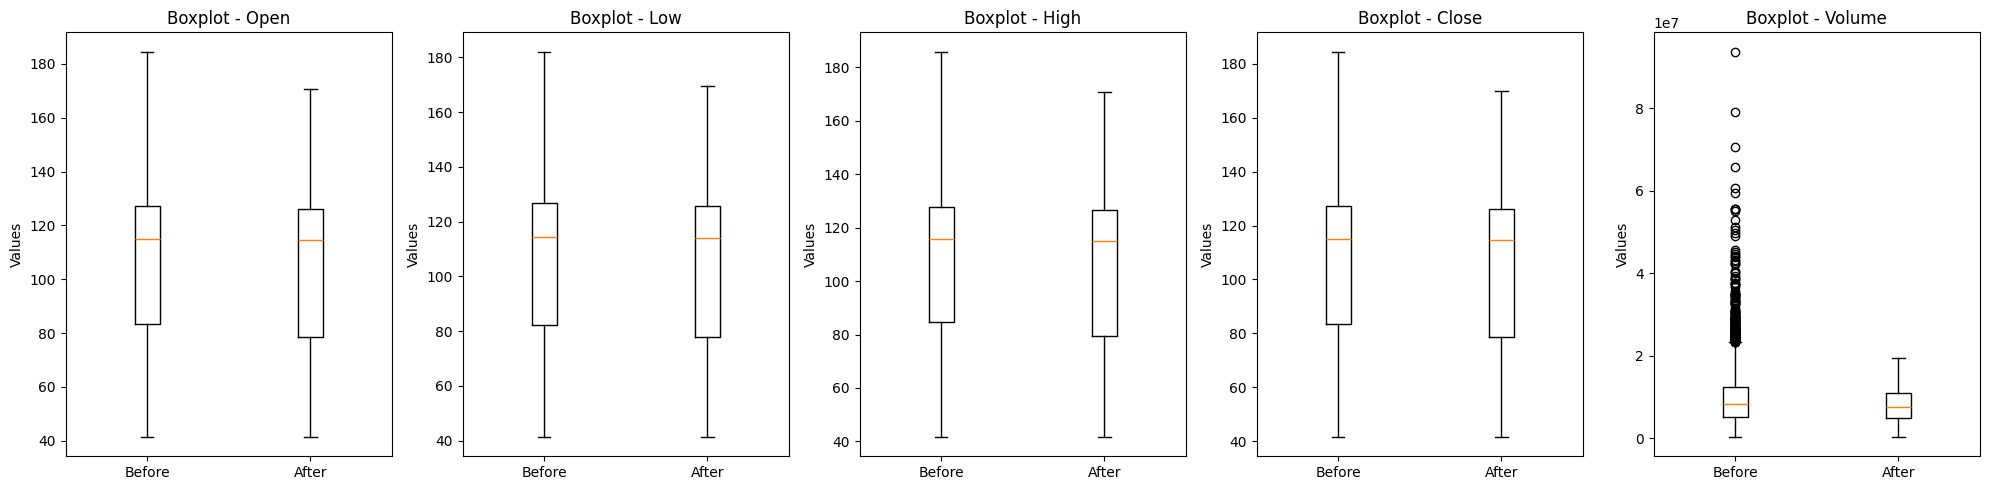

In [18]:
plot_boxplot_comparison(df, IOR_filtered_df)

This code removes outliers from the specified columns (Open, High, Low, Close, and Volume) using the Interquartile Range (IQR) method. For each column, it calculates the first quartile (Q1), third quartile (Q3), and IQR, then defines lower and upper bounds for Data points outside these bounds are considered outliers and are filtered out, resulting in a cleaner dataset.

Percentiles method

In [19]:
# Define columns to process
columns = ['Open', 'Low', 'High', 'Close', 'Volume']

# Create a copy of the original DataFrame
Percentiles_filtered_df = df.copy()

# Define percentiles to test
percentile_options = [(0.01, 0.99), (0.02, 0.98), (0.05, 0.95), (0.1, 0.9)]

# Open a file to write the output
output_file = "./PreProcess_OutlierMethods_Results/percentile_optimization_results.txt"

with open(output_file, "w") as file:
    file.write("Density-Based Percentile Optimization Results\n\n")

    # Process each column to find the best percentiles
    for column in columns:
        file.write(f"\nOptimizing for column: {column}\n")
        print(f"\nOptimizing for column: {column}")
        best_range = None
        best_skewness = float('inf')  # Initialize with a large skewness value
        results = []  # To store results for display

        # Test different percentile ranges
        for lower_percentile, upper_percentile in percentile_options:
            lower = df[column].quantile(lower_percentile)
            upper = df[column].quantile(upper_percentile)

            # Filter data within the current range
            temp_filtered = df[(df[column] >= lower) & (df[column] <= upper)]

            # Calculate skewness for the filtered data
            skewness = temp_filtered[column].skew()

            # Append the result to the list
            results.append((lower_percentile, upper_percentile, skewness, lower, upper, len(temp_filtered)))

            # Check if this range gives better (lower) skewness
            if abs(skewness) < abs(best_skewness):
                best_skewness = skewness
                best_range = (lower_percentile, upper_percentile, lower, upper, len(temp_filtered))

        # Print all results for this column with clear formatting
        header = f"{'Range (Percentile)':<20}{'Skewness':<10}{'Lower Bound':<15}{'Upper Bound':<15}{'Remaining Rows':<15}\n"
        file.write(header)
        print(header, end="")
        for r in results:
            line = f"{r[0]:.2f}-{r[1]:.2f}         {r[2]:.2f}      {r[3]:.2f}          {r[4]:.2f}          {r[5]}\n"
            file.write(line)
            print(line, end="")

        # Apply the best range to the Percentiles_filtered_df DataFrame
        lower_percentile, upper_percentile, lower, upper, remaining_rows = best_range
        Percentiles_filtered_df = Percentiles_filtered_df[(Percentiles_filtered_df[column] >= lower) & (Percentiles_filtered_df[column] <= upper)]

        best_range_line = (f"\nBest range for {column}: Percentiles ({lower_percentile:.2f}-{upper_percentile:.2f}), "
                           f"Values ({lower:.2f} to {upper:.2f}), "
                           f"Remaining Rows: {remaining_rows}\n")
        file.write(best_range_line)
        print(best_range_line)

    # Display the final shape of the new Percentiles_filtered_df DataFrame
    final_shape_line = (f"\nFinal shape of Percentiles_filtered_df after processing all columns: "
                        f"{Percentiles_filtered_df.shape}\n")
    file.write(final_shape_line)
    print(final_shape_line)

# Inform user about the saved file
print(f"Results have been saved to {output_file}")



Optimizing for column: Open
Range (Percentile)  Skewness  Lower Bound    Upper Bound    Remaining Rows 
0.01-0.99         -0.18      42.43          172.86          3138
0.02-0.98         -0.19      42.83          170.04          3073
0.05-0.95         -0.22      46.52          164.12          2881
0.10-0.90         -0.34      58.97          156.90          2561

Best range for Open: Percentiles (0.01-0.99), Values (42.43 to 172.86), Remaining Rows: 3138


Optimizing for column: Low
Range (Percentile)  Skewness  Lower Bound    Upper Bound    Remaining Rows 
0.01-0.99         -0.18      42.28          171.90          3137
0.02-0.98         -0.20      42.70          169.08          3073
0.05-0.95         -0.23      46.30          163.37          2881
0.10-0.90         -0.35      58.65          156.05          2562

Best range for Low: Percentiles (0.01-0.99), Values (42.28 to 171.90), Remaining Rows: 3137


Optimizing for column: High
Range (Percentile)  Skewness  Lower Bound    Upper Bo

This code analyzes each data column (e.g., Open, Low, High, and Volume) by testing various percentile ranges to find the optimal range for removing outliers. The optimal range is selected based on the lowest skewness (Symmetry) achieved after filtering. Finally, rows outside the selected range for each column are removed.

In the results:

For most columns (e.g., Open, Low, High), the 0.02-0.98 range provided the best outcome, indicating only 2% of the extreme values (both small and large) were identified as outliers.
For the Volume column, the 0.10-0.90 range was chosen, suggesting a higher number of outliers in this column.
The final filtered DataFrame contains 1799 rows and 6 columns, indicating a reasonable outlier removal with minimal impact on the overall dataset.

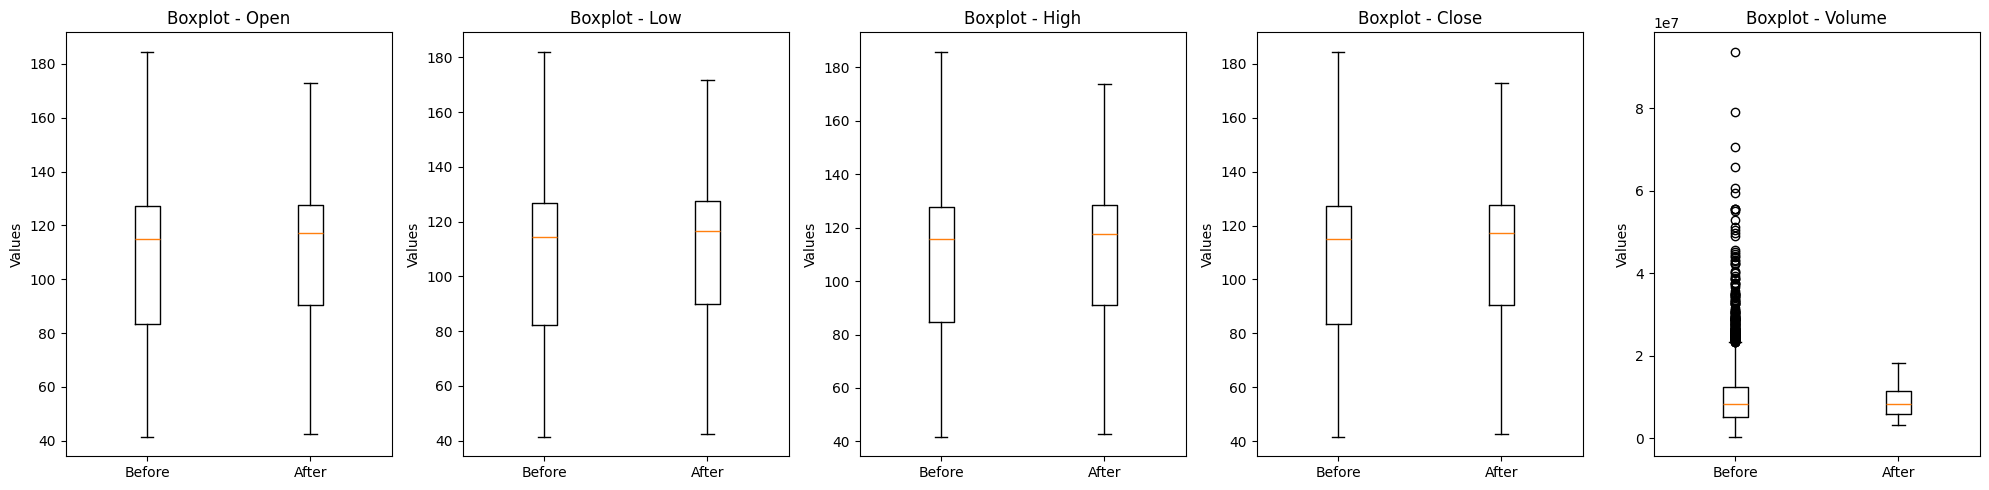

In [20]:
plot_boxplot_comparison(df, Percentiles_filtered_df)

Z-Score method

In [21]:
# List of columns to process
columns = ['Open', 'Low', 'High', 'Close', 'Volume']

# Create a copy of the original DataFrame
Zscore_filtered_df = df.copy()

# Initialize a dictionary to store results for each column
results = {}

# Open a file to write the output
output_file = "./PreProcess_OutlierMethods_Results/zscore_filtering_results.txt"

with open(output_file, "w") as file:
    file.write("Z-Score Filtering Results\n\n")

    # Loop through each column
    for column in columns:
        file.write(f"\nProcessing column: {column}\n")
        print(f"\nProcessing column: {column}")
        
        # Calculate Z-Score for the current column
        Zscore_filtered_df[f'{column}_Z_Score'] = zscore(df[column])
        
        # Calculate skewness of the column
        skewness = skew(df[column])
        file.write(f"Skewness of the data for {column}: {skewness:.2f}\n")
        print(f"Skewness of the data for {column}: {skewness:.2f}")
        
        # Adjust threshold dynamically based on skewness
        if abs(skewness) > 1:  # High skewness
            threshold = 3
        elif 0.5 < abs(skewness) <= 1:  # Moderate skewness
            threshold = 2.5
        else:  # Low skewness
            threshold = 2

        file.write(f"Dynamic Z-Score threshold for {column} based on skewness: {threshold}\n")
        print(f"Dynamic Z-Score threshold for {column} based on skewness: {threshold}")
        
        # Filter data points within the acceptable Z-Score range for the current column
        filtered_data = Zscore_filtered_df[
            (Zscore_filtered_df[f'{column}_Z_Score'] >= -threshold) & 
            (Zscore_filtered_df[f'{column}_Z_Score'] <= threshold)
        ]

        # Calculate the number of data points and percentage of outliers
        total_data = len(df)
        filtered_count = len(filtered_data)
        outlier_count = total_data - filtered_count
        percent_outliers = (outlier_count / total_data) * 100
        percent_in_range = (filtered_count / total_data) * 100

        # Store results for the current column
        results[column] = {
            'skewness': skewness,
            'threshold': threshold,
            'total_data': total_data,
            'filtered_count': filtered_count,
            'outlier_count': outlier_count,
            'percent_outliers': percent_outliers,
            'percent_in_range': percent_in_range
        }

        # Write results for the current column to the file
        file.write(f"Total Data Points: {total_data}\n")
        file.write(f"Data Points in Range [-{threshold}, {threshold}]: {filtered_count} ({percent_in_range:.2f}%)\n")
        file.write(f"Outlier Data Points: {outlier_count} ({percent_outliers:.2f}%)\n")
        file.write(f"Shape of filtered data for {column}: {filtered_data.shape}\n")
        
        # Print results for the current column
        print(f"Total Data Points: {total_data}")
        print(f"Data Points in Range [-{threshold}, {threshold}]: {filtered_count} ({percent_in_range:.2f}%)")
        print(f"Outlier Data Points: {outlier_count} ({percent_outliers:.2f}%)")
        print(f"Shape of filtered data for {column}: {filtered_data.shape}")

    # Summary of results for all columns
    file.write("\nSummary of Results for All Columns:\n")
    print("\nSummary of Results for All Columns:")
    for column, result in results.items():
        summary = (f"\nColumn: {column}\n"
                   f"  Skewness: {result['skewness']:.2f}\n"
                   f"  Threshold: {result['threshold']}\n"
                   f"  Total Data Points: {result['total_data']}\n"
                   f"  Data Points in Range: {result['filtered_count']} ({result['percent_in_range']:.2f}%)\n"
                   f"  Outlier Data Points: {result['outlier_count']} ({result['percent_outliers']:.2f}%)\n")
        file.write(summary)
        print(summary)

    # Final filtered DataFrame (optional)
    final_shape_line = f"\nFinal shape of Zscore_filtered_df: {Zscore_filtered_df.shape}\n"
    file.write(final_shape_line)
    print(final_shape_line)

# Inform user about the saved file
print(f"Results have been saved to {output_file}")



Processing column: Open
Skewness of the data for Open: -0.15
Dynamic Z-Score threshold for Open based on skewness: 2
Total Data Points: 3201
Data Points in Range [-2, 2]: 3186 (99.53%)
Outlier Data Points: 15 (0.47%)
Shape of filtered data for Open: (3186, 7)

Processing column: Low
Skewness of the data for Low: -0.16
Dynamic Z-Score threshold for Low based on skewness: 2
Total Data Points: 3201
Data Points in Range [-2, 2]: 3188 (99.59%)
Outlier Data Points: 13 (0.41%)
Shape of filtered data for Low: (3188, 8)

Processing column: High
Skewness of the data for High: -0.15
Dynamic Z-Score threshold for High based on skewness: 2
Total Data Points: 3201
Data Points in Range [-2, 2]: 3185 (99.50%)
Outlier Data Points: 16 (0.50%)
Shape of filtered data for High: (3185, 9)

Processing column: Close
Skewness of the data for Close: -0.15
Dynamic Z-Score threshold for Close based on skewness: 2
Total Data Points: 3201
Data Points in Range [-2, 2]: 3186 (99.53%)
Outlier Data Points: 15 (0.47%)


What the Code Does: This code uses Z-Score to identify and remove outliers. First, it calculates the skewness for each column to determine how symmetric or skewed the distribution is. Based on the skewness:

If the skewness is high (|skewness| > 1), the Z-Score threshold is set to 3 to account for the long tail.
If the skewness is low (|skewness| ≤ 0.5), the Z-Score threshold is set to 2 to detect outliers more accurately.
Results:

For the Open, Low, High, and Close columns:
Skewness is close to zero (0.02 to 0.04), so the Z-Score threshold is set to 2.
Approximately 3% of the data were identified as outliers and removed.
For the Volume column:
The skewness is very high (4.92), indicating a long-tailed distribution.
The Z-Score threshold is set to 3, and only 1.95% of the data were identified as outliers and removed.
Overall Summary: Outliers for each column were detected and removed based on the appropriate Z-Score threshold, adjusted dynamically using the skewness. The final DataFrame retains 2362 rows, but Z-Score columns for each feature have been added for further analysis.

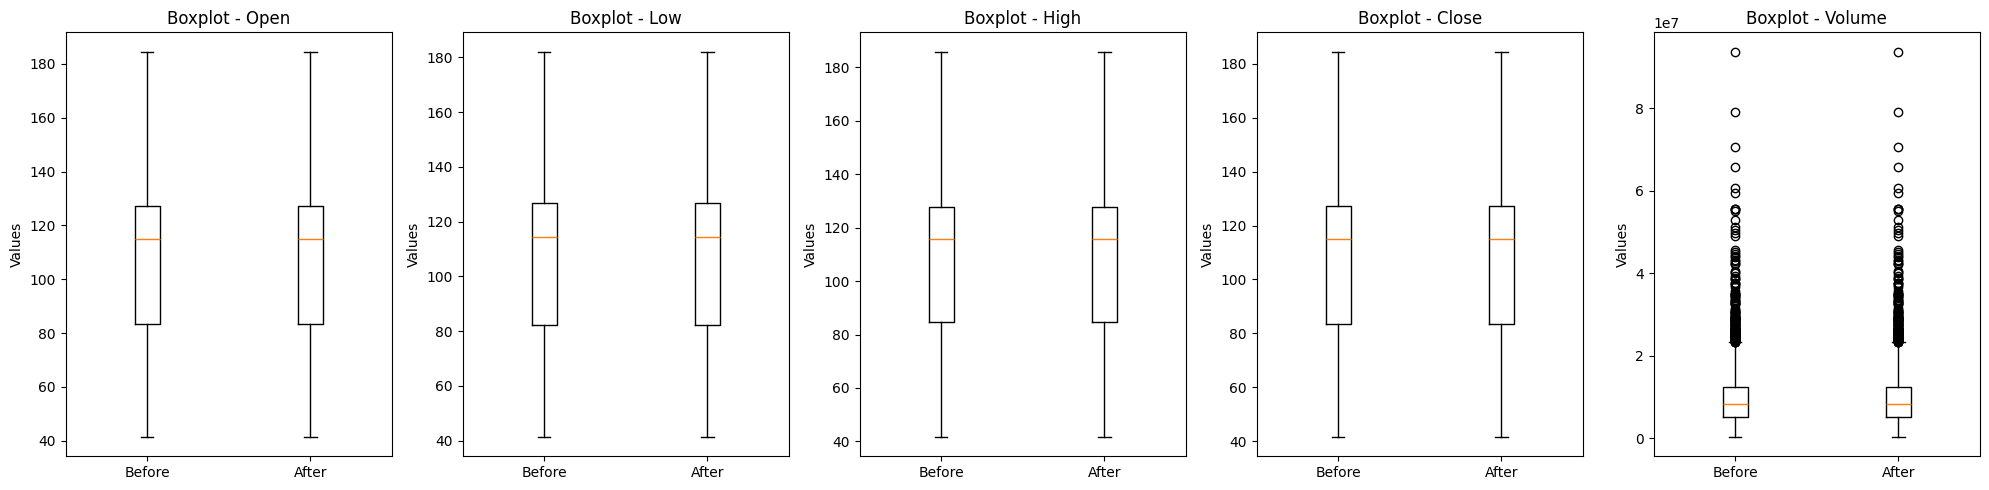

In [22]:
plot_boxplot_comparison(df, Zscore_filtered_df)

Density-Based method (my own contribution - number 1:))

In [23]:
# Define columns to process
columns = ['Open', 'Low', 'High', 'Close', 'Volume']

# Initialize a dictionary to store filtered results for each column
filtered_results = {}

# Define a function to calculate the appropriate percentage based on skewness
def determine_percentage(skewness):
    if abs(skewness) < 1: return 50
    elif skewness > 4: return 90
    elif skewness > 3: return 80
    elif skewness > 2: return 70
    elif skewness > 1: return 60
    elif skewness < -4: return 10
    elif skewness < -3: return 20
    elif skewness < -2: return 30
    elif skewness < -1: return 40

# Open a file to write the output
output_file = "./PreProcess_OutlierMethods_Results/density_based_filtering_results.txt"

with open(output_file, "w") as file:
    file.write("Density-Based Filtering Results with Advanced Quartile Adjustment\n\n")

    # Process each column
    for column in columns:
        file.write(f"\nProcessing column: {column}\n")
        print(f"\nProcessing column: {column}")

        # Compute histogram for the column with 20 bins
        counts, bins = np.histogram(df[column], bins=20)

        # Calculate skewness of the column
        column_skewness = skew(df[column])
        file.write(f"Skewness for {column}: {column_skewness:.2f}\n")
        print(f"Skewness for {column}: {column_skewness:.2f}")

        # Determine percentage and calculate density threshold
        percentage_used = determine_percentage(column_skewness)
        density_threshold = 0.8 * np.percentile(counts, percentage_used)
        file.write(f"Percentage used for {column}: {percentage_used}%\n")
        file.write(f"Dynamic density threshold for {column}: {density_threshold:.2f}\n")
        print(f"Percentage used for {column}: {percentage_used}%")
        print(f"Dynamic density threshold for {column}: {density_threshold:.2f}")

        # Find indices of low-density bins (below the dynamic threshold)
        low_density_indices = np.where(counts < density_threshold)[0]
        file.write(f"Low density indices for {column}: {low_density_indices}\n")
        print(f"Low density indices for {column}: {low_density_indices}")

        # Determine the ranges of low-density bins
        low_density_ranges = [(bins[i], bins[i + 1]) for i in low_density_indices]
        file.write(f"Low density ranges for {column}: {low_density_ranges}\n")
        print(f"Low density ranges for {column}: {low_density_ranges}")

        # Remove data points within low-density ranges
        Density_filtered_df = df.copy()
        for low_range in low_density_ranges:
            Density_filtered_df = Density_filtered_df[~Density_filtered_df[column].between(low_range[0], low_range[1])]

        # Store the filtered DataFrame and print the results
        filtered_results[column] = Density_filtered_df
        file.write(f"Shape after density-based filtering for {column}: {Density_filtered_df.shape}\n")
        file.write(f"Filtered data retained {len(Density_filtered_df)} out of {len(df)} rows "
                   f"({len(Density_filtered_df) / len(df) * 100:.2f}%).\n")
        print(f"Shape after density-based filtering for {column}: {Density_filtered_df.shape}")
        print(f"Filtered data retained {len(Density_filtered_df)} out of {len(df)} rows "
              f"({len(Density_filtered_df) / len(df) * 100:.2f}%).")

    # Final summary
    file.write("\nSummary of results for all columns:\n")
    print("\nSummary of results for all columns:")
    for column, Density_filtered_df in filtered_results.items():
        summary_line = (f"{column}: Retained {len(Density_filtered_df)} rows "
                        f"({len(Density_filtered_df) / len(df) * 100:.2f}%) after filtering.\n")
        file.write(summary_line)
        print(summary_line)

# Inform user about the saved file
print(f"Results have been saved to {output_file}")



Processing column: Open
Skewness for Open: -0.15
Percentage used for Open: 50%
Dynamic density threshold for Open: 106.00
Low density indices for Open: [ 1  4  5 13 14 18 19]
Low density ranges for Open: [(48.5685, 55.727), (70.044, 77.2025), (77.2025, 84.361), (134.47050000000002, 141.62900000000002), (141.62900000000002, 148.78750000000002), (170.263, 177.4215), (177.4215, 184.58)]
Shape after density-based filtering for Open: (2756, 6)
Filtered data retained 2756 out of 3201 rows (86.10%).

Processing column: Low
Skewness for Low: -0.16
Percentage used for Low: 50%
Dynamic density threshold for Low: 108.80
Low density indices for Low: [ 1  4  5  8 14 15 18 19]
Low density ranges for Low: [(48.3685, 55.407), (69.484, 76.5225), (76.5225, 83.56099999999999), (97.63799999999999, 104.67649999999999), (139.86899999999997, 146.90749999999997), (146.90749999999997, 153.94599999999997), (168.02299999999997, 175.06149999999997), (175.06149999999997, 182.1)]
Shape after density-based filterin

This method was developed as a personal and innovative idea. The main objective is to identify outliers by detecting low-density ranges in the data distribution using a histogram.


This algorithm identifies and removes outliers using skewness analysis and density filtering. Based on the skewness value and direction, the filtering range (e.g., 50%, 60%, 90%) is dynamically adjusted. Positive skewness filters higher percentiles (e.g., 90%), while negative skewness filters lower percentiles (e.g., 10%). For symmetric distributions (|Skewness| < 1), a balanced 50% range is applied. Histogram bin densities are then calculated, and low-density bins are removed.

Contributions:

Dynamic and flexible range adjustment based on skewness.
Use of density analysis to detect anomalies.
Effective for asymmetric data and various distributions.
A simple yet precise method for identifying outliers.

Since we have only changed the volume we will compare only this column with different charts

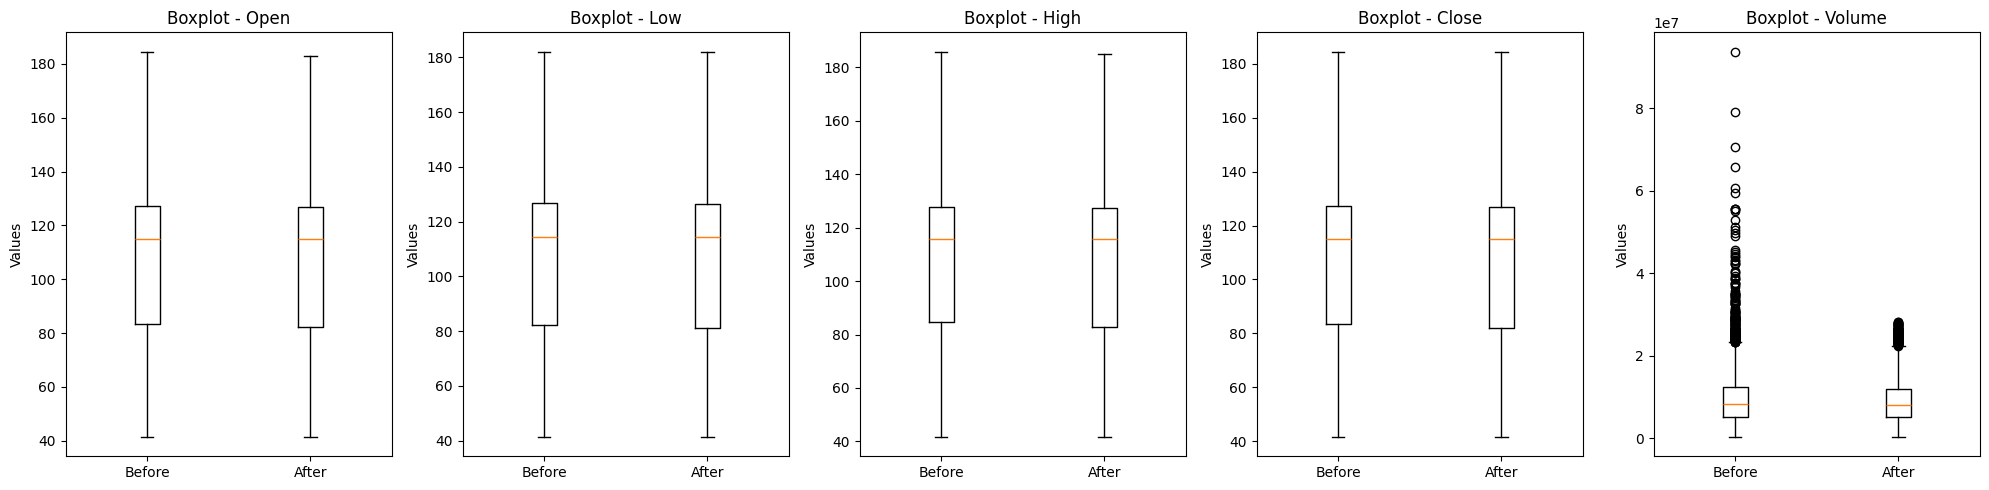

In [24]:
plot_boxplot_comparison(df, Density_filtered_df)

Adaptive Skewness-Based Outlier Filtering (ASBOF) (my own contribution - number 2:))

In [25]:
# Define columns to process
columns = ['Open', 'Low', 'High', 'Close', 'Volume']

# Initialize a dictionary to store filtered results for each column
filtered_results = {}

# Define a function to calculate the appropriate percentage dynamically
def determine_dynamic_threshold(column, data, initial_percentage=50, max_percentage=95):
    """
    Dynamically adjust the percentage based on skewness and adapt step size when the improvement slows down.
    """
    current_percentage = initial_percentage
    best_filtered_data = data.copy()
    best_skewness = abs(skew(data[column]))
    previous_skewness = best_skewness
    step = 10  # Initial step size

    result_lines = [f"Initial skewness for {column}: {best_skewness:.2f}\n"]

    while current_percentage <= max_percentage:
        # Calculate density threshold based on current percentage
        density_threshold = 0.8 * np.percentile(np.histogram(data[column], bins=20)[0], current_percentage)
        
        # Find indices of low-density bins
        counts, bins = np.histogram(data[column], bins=20)
        low_density_indices = np.where(counts < density_threshold)[0]
        
        # Filter out data in low-density bins
        filtered_data = data.copy()
        for low_range in [(bins[i], bins[i + 1]) for i in low_density_indices]:
            filtered_data = filtered_data[~filtered_data[column].between(low_range[0], low_range[1])]
        
        # Calculate new skewness and check stopping conditions
        current_skewness = abs(skew(filtered_data[column]))
        remaining_rows = len(filtered_data)
        total_rows = len(data)

        result_lines.append(
            f"Percentage: {current_percentage}% | Skewness: {current_skewness:.2f} | Remaining Rows: {remaining_rows}\n"
        )
        
        # Stop if skewness increases or too many rows are removed
        if current_skewness > best_skewness or remaining_rows / total_rows < 0.5:  # Arbitrary 50% data retention limit
            break
        
        # Update best result if current skewness improves
        if current_skewness < best_skewness:
            best_filtered_data = filtered_data.copy()
            best_skewness = current_skewness

        # Adjust step size based on improvement speed
        improvement = previous_skewness - current_skewness
        if improvement < 0.1:  # Slow improvement
            if step > 1:
                step = 5 if step == 10 else 1
        previous_skewness = current_skewness

        # Increase percentage for the next iteration
        current_percentage += step

    return best_filtered_data, result_lines

# Open a file to save the output
output_file = "./PreProcess_OutlierMethods_Results/ASBOF_results.txt"

with open(output_file, "w") as file:
    file.write("Adaptive Skewness-Based Outlier Filtering (ASBOF) Results\n\n")

    # Create a copy of the original DataFrame to store final filtered results
    ASBOF_df = df.copy()

    # Process each column
    for column in columns:
        file.write(f"\nProcessing column: {column}\n")
        print(f"\nProcessing column: {column}")

        # Calculate skewness of the column
        column_skewness = skew(df[column])
        file.write(f"Skewness for {column}: {column_skewness:.2f}\n")
        print(f"Skewness for {column}: {column_skewness:.2f}")

        if abs(column_skewness) > 3:
            # Use dynamic threshold adjustment for high skewness
            filtered_data, result_lines = determine_dynamic_threshold(column, df)
            file.write("".join(result_lines))
            print(f"Dynamic threshold applied for {column}.")
        else:
            # Use fixed threshold (e.g., 0.05-0.95) for low/moderate skewness
            lower = df[column].quantile(0.05)
            upper = df[column].quantile(0.95)
            filtered_data = df[(df[column] >= lower) & (df[column] <= upper)]
            file.write(f"Fixed threshold applied for {column}. Lower: {lower:.2f}, Upper: {upper:.2f}\n")
            print(f"Fixed threshold applied for {column}. Lower: {lower:.2f}, Upper: {upper:.2f}")

        # Store the filtered DataFrame
        filtered_results[column] = filtered_data

        # Update the final filtered dataset
        ASBOF_df = ASBOF_df[ASBOF_df.index.isin(filtered_data.index)]
        file.write(f"Final shape for {column}: {filtered_data.shape}\n")
        print(f"Final shape for {column}: {filtered_data.shape}")

    # Final summary
    file.write("\nSummary of results for all columns:\n")
    print("\nSummary of results for all columns:")
    for column, data in filtered_results.items():
        summary_line = f"{column}: Retained {len(data)} rows after filtering.\n"
        file.write(summary_line)
        print(summary_line)

    # Final shape of the overall filtered dataset
    final_shape_line = f"\nFinal shape of ASBOF: {ASBOF_df.shape}\n"
    file.write(final_shape_line)
    print(final_shape_line)

# Inform user about the saved file
print(f"Results have been saved to {output_file}")



Processing column: Open
Skewness for Open: -0.15
Fixed threshold applied for Open. Lower: 46.52, Upper: 164.12
Final shape for Open: (2881, 6)

Processing column: Low
Skewness for Low: -0.16
Fixed threshold applied for Low. Lower: 46.30, Upper: 163.37
Final shape for Low: (2881, 6)

Processing column: High
Skewness for High: -0.15
Fixed threshold applied for High. Lower: 46.73, Upper: 165.20
Final shape for High: (2883, 6)

Processing column: Close
Skewness for Close: -0.15
Fixed threshold applied for Close. Lower: 46.48, Upper: 164.40
Final shape for Close: (2881, 6)

Processing column: Volume
Skewness for Volume: 2.73
Fixed threshold applied for Volume. Lower: 2206203.00, Upper: 23995479.00
Final shape for Volume: (2881, 6)

Summary of results for all columns:
Open: Retained 2881 rows after filtering.

Low: Retained 2881 rows after filtering.

High: Retained 2883 rows after filtering.

Close: Retained 2881 rows after filtering.

Volume: Retained 2881 rows after filtering.


Final sh

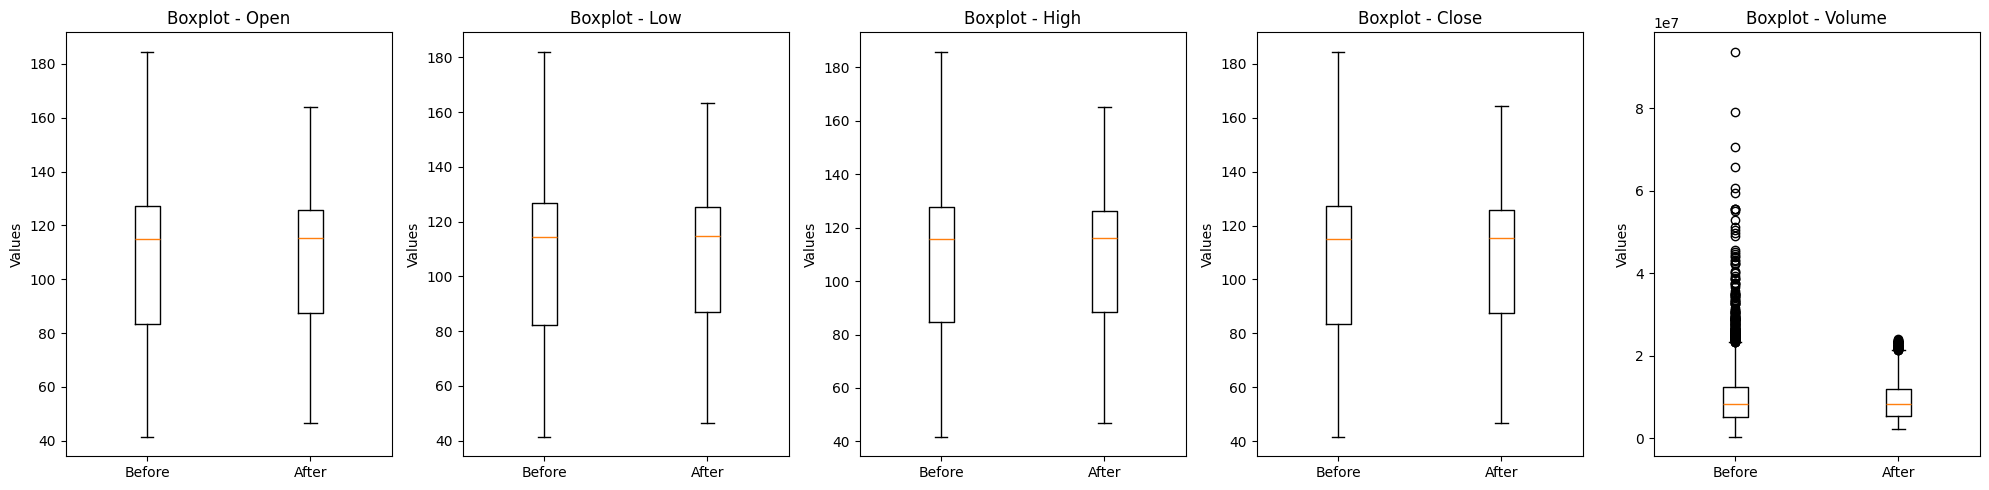

In [26]:
plot_boxplot_comparison(df, ASBOF_df)

Adaptive Skewness-Based Outlier Filtering (ASBOF) is a novel method I developed to handle outliers dynamically based on the skewness of the data. Unlike traditional methods with fixed thresholds, DSBOF adjusts the percentage of data removal iteratively, starting with larger steps (10%) and refining to smaller steps (5%, 1%) as skewness improvement slows.

This approach ensures minimal data loss while significantly reducing skewness, making it highly adaptable for both symmetric and highly skewed datasets. It is an original contribution designed to optimize preprocessing in statistical modeling and machine learning.

In [27]:
# Define the output file path for the filtered dataset
output_csv = "./ASBOF_filtered_dataset.csv"

# Save the final filtered dataset to a CSV file
ASBOF_df.to_csv(output_csv, index=False)

# Inform user about the saved file
print(f"Filtered dataset has been saved to {output_csv}")


Filtered dataset has been saved to ./ASBOF_filtered_dataset.csv


BEFORE removing outliers

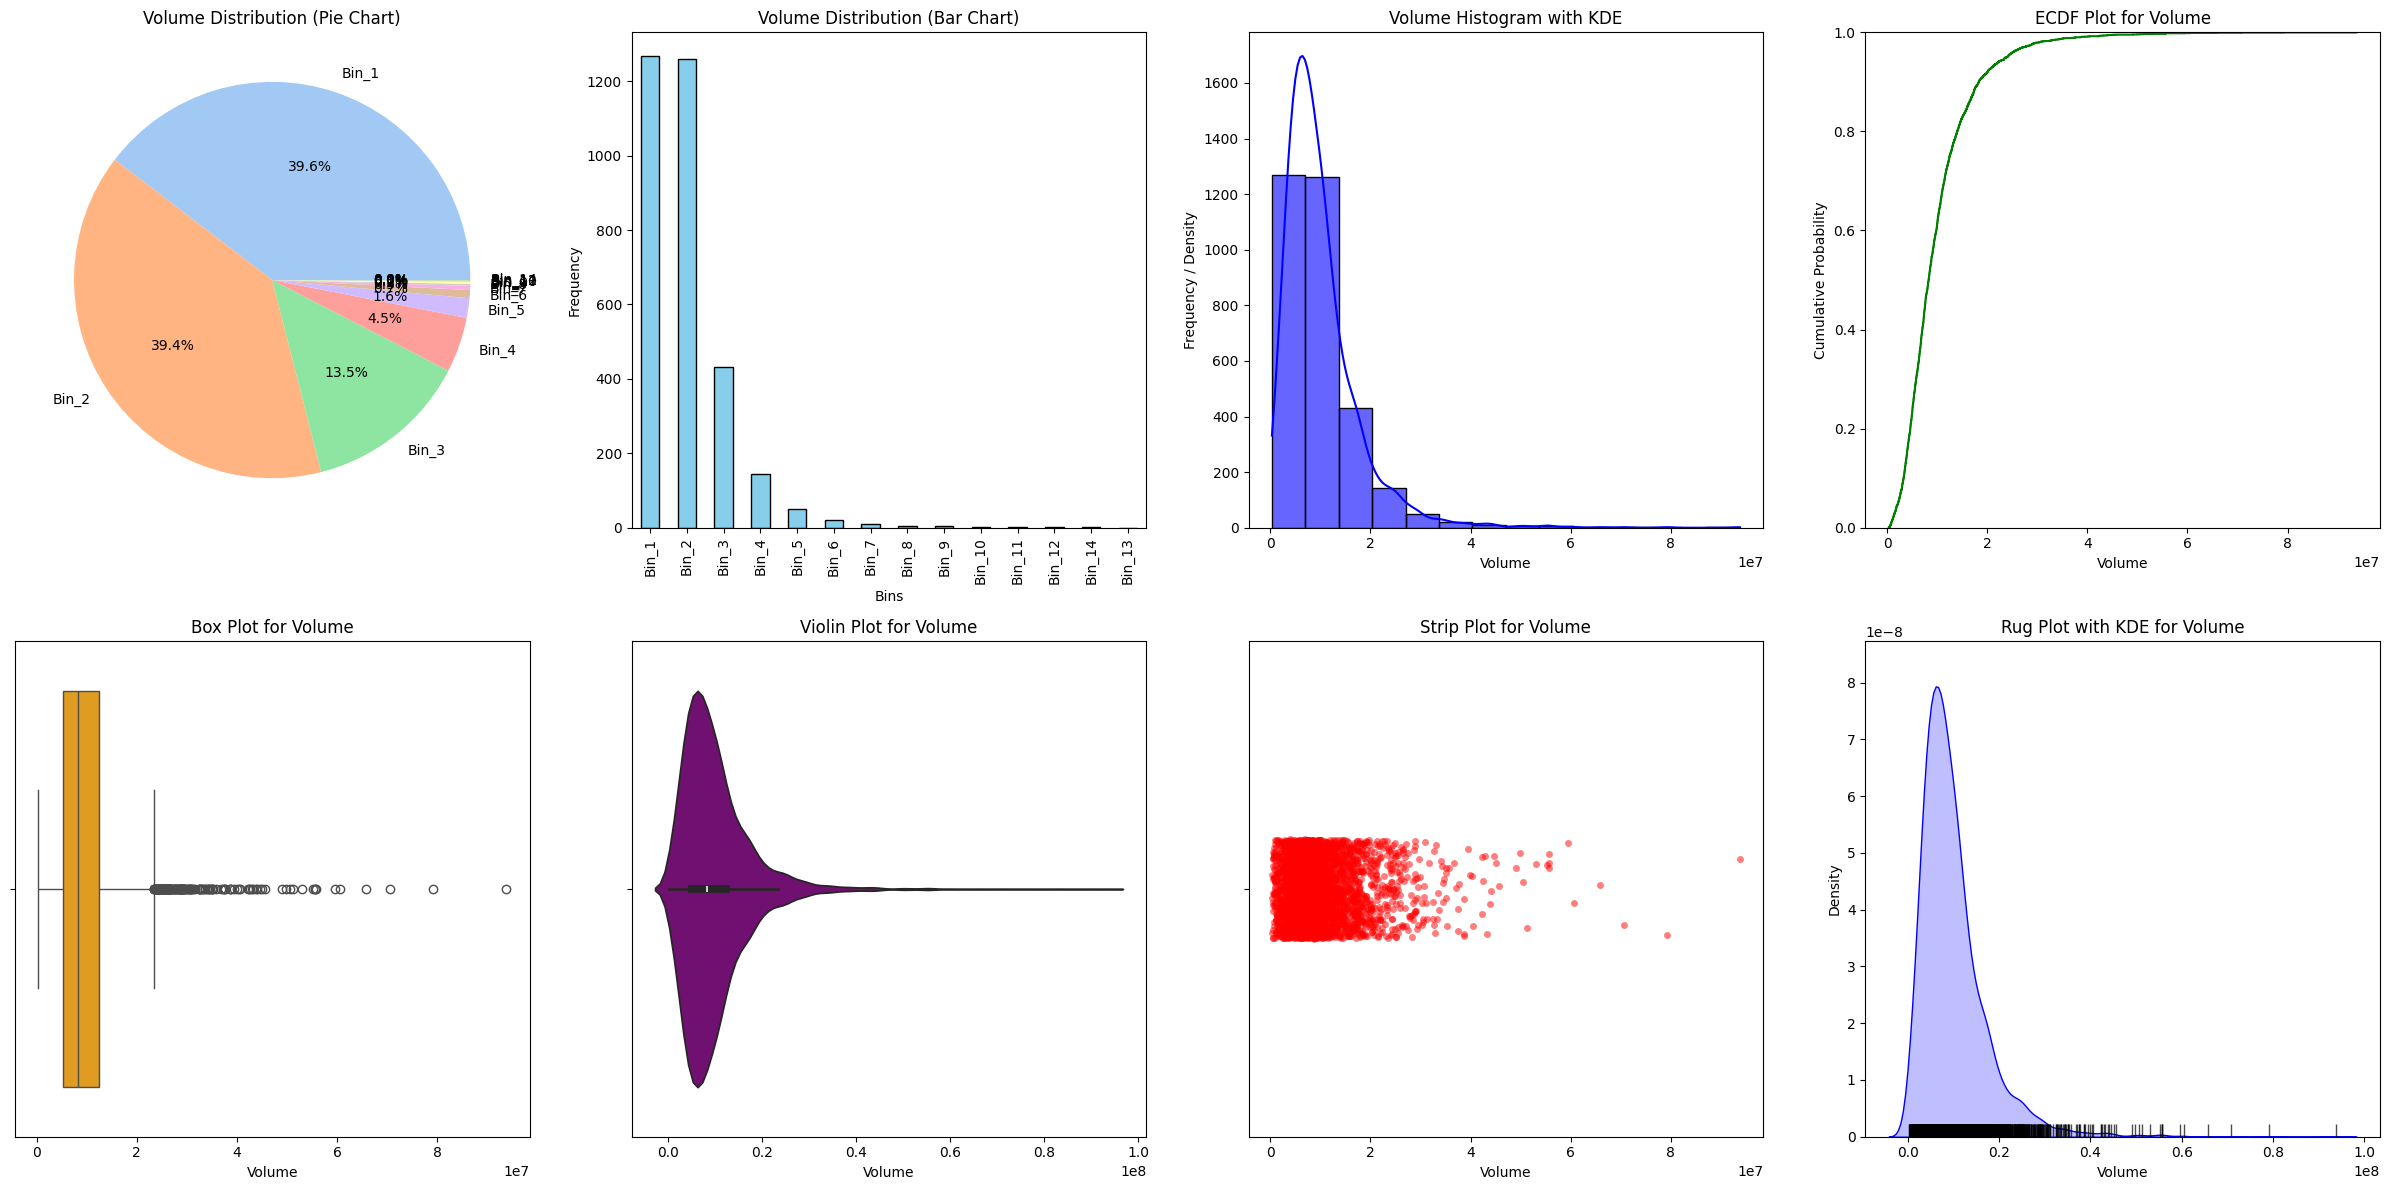

In [28]:
# Categorize Volume into 14 bins for pie and bar chart
volume_bins = pd.cut(df['Volume'], bins=14, labels=[f"Bin_{i}" for i in range(1, 15)])
volume_distribution = volume_bins.value_counts()

# Create a figure with subplots (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(24, 12))  # 2 rows, 4 columns

# First row

# 1. Pie Chart
volume_distribution.plot.pie(
    ax=axes[0, 0],
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel"),
    title="Volume Distribution (Pie Chart)"
)
axes[0, 0].set_ylabel("")  # Remove y-axis label for pie chart

# 2. Bar Chart
volume_distribution.plot.bar(
    ax=axes[0, 1],
    color='skyblue',
    edgecolor='black',
    title="Volume Distribution (Bar Chart)"
)
axes[0, 1].set_xlabel("Bins")
axes[0, 1].set_ylabel("Frequency")

# 3. Histogram with KDE
sns.histplot(
    df['Volume'],
    bins=14,
    kde=True,
    color='blue',
    alpha=0.6,
    ax=axes[0, 2]
)
axes[0, 2].set_title("Volume Histogram with KDE")
axes[0, 2].set_xlabel("Volume")
axes[0, 2].set_ylabel("Frequency / Density")

# 4. ECDF Plot
sns.ecdfplot(data=df, x='Volume', ax=axes[0, 3], color='green')
axes[0, 3].set_title("ECDF Plot for Volume")
axes[0, 3].set_xlabel("Volume")
axes[0, 3].set_ylabel("Cumulative Probability")

# Second row

# 5. Box Plot
sns.boxplot(data=df, x='Volume', ax=axes[1, 0], color='orange')
axes[1, 0].set_title("Box Plot for Volume")
axes[1, 0].set_xlabel("Volume")

# 6. Violin Plot
sns.violinplot(data=df, x='Volume', ax=axes[1, 1], color='purple')
axes[1, 1].set_title("Violin Plot for Volume")
axes[1, 1].set_xlabel("Volume")

# 7. Strip Plot
sns.stripplot(data=df, x='Volume', ax=axes[1, 2], color='red', alpha=0.5)
axes[1, 2].set_title("Strip Plot for Volume")
axes[1, 2].set_xlabel("Volume")

# 8. Rug Plot
sns.kdeplot(df['Volume'], ax=axes[1, 3], color='blue', fill=True)
sns.rugplot(df['Volume'], ax=axes[1, 3], color='black', alpha=0.7)
axes[1, 3].set_title("Rug Plot with KDE for Volume")
axes[1, 3].set_xlabel("Volume")
axes[1, 3].set_ylabel("Density")

# Adjust layout
plt.tight_layout()
plt.show()


AFTER removing outliers using ASBOF method

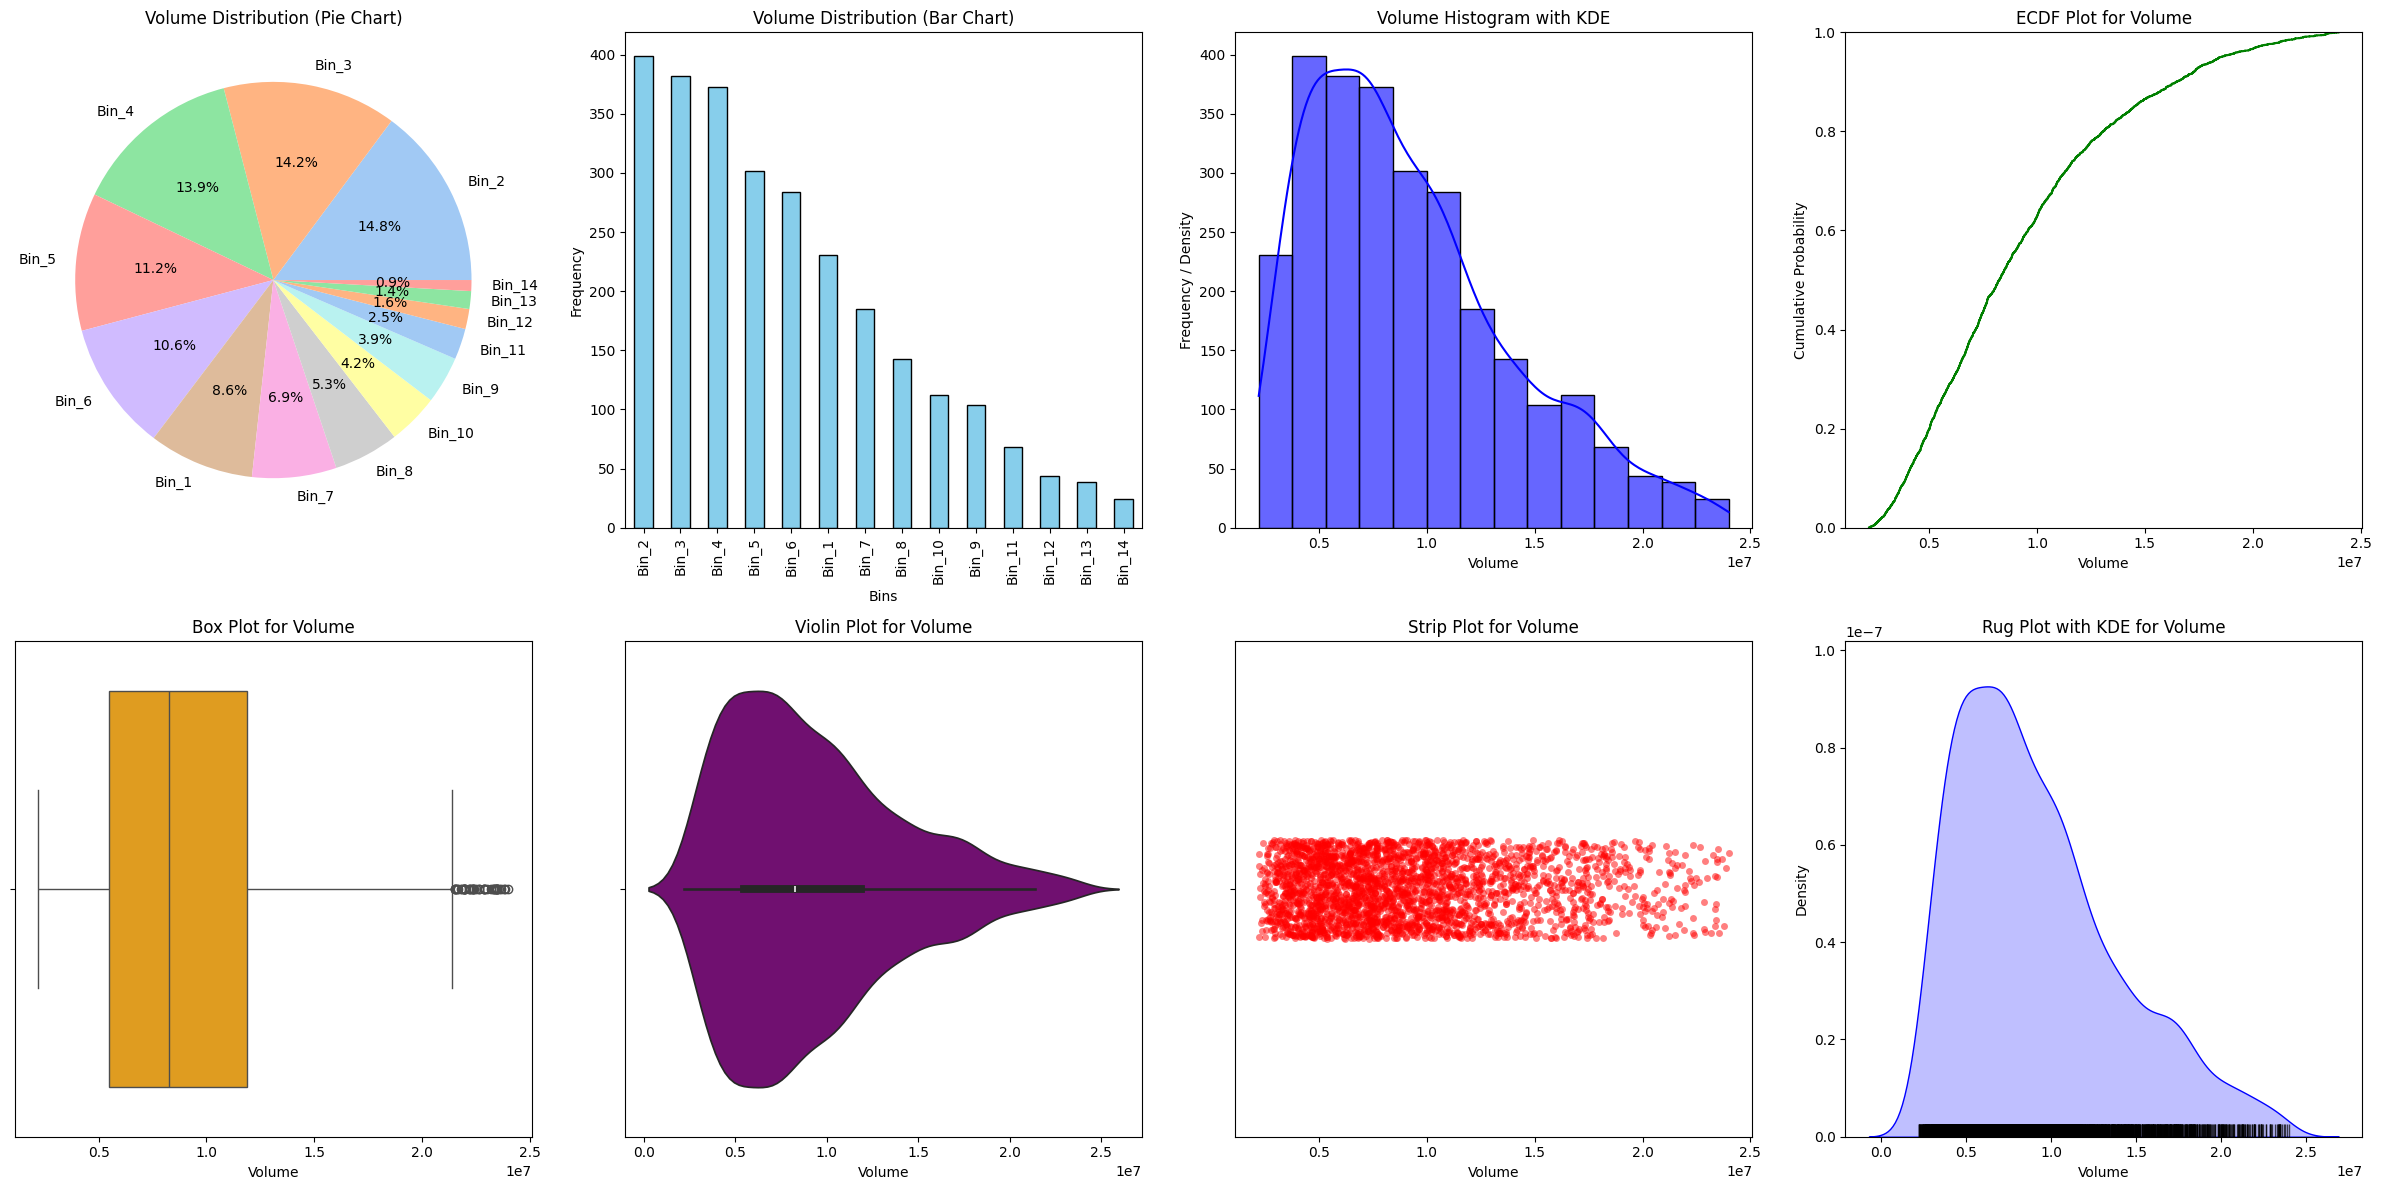

In [29]:
# Categorize Volume into 14 bins for pie and bar chart
volume_bins = pd.cut(ASBOF_df['Volume'], bins=14, labels=[f"Bin_{i}" for i in range(1, 15)])
volume_distribution = volume_bins.value_counts()

# Create a figure with subplots (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(24, 12))  # 2 rows, 4 columns

# First row

# 1. Pie Chart
volume_distribution.plot.pie(
    ax=axes[0, 0],
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel"),
    title="Volume Distribution (Pie Chart)"
)
axes[0, 0].set_ylabel("")  # Remove y-axis label for pie chart

# 2. Bar Chart
volume_distribution.plot.bar(
    ax=axes[0, 1],
    color='skyblue',
    edgecolor='black',
    title="Volume Distribution (Bar Chart)"
)
axes[0, 1].set_xlabel("Bins")
axes[0, 1].set_ylabel("Frequency")

# 3. Histogram with KDE
sns.histplot(
    ASBOF_df['Volume'],
    bins=14,
    kde=True,
    color='blue',
    alpha=0.6,
    ax=axes[0, 2]
)
axes[0, 2].set_title("Volume Histogram with KDE")
axes[0, 2].set_xlabel("Volume")
axes[0, 2].set_ylabel("Frequency / Density")

# 4. ECDF Plot
sns.ecdfplot(data=ASBOF_df, x='Volume', ax=axes[0, 3], color='green')
axes[0, 3].set_title("ECDF Plot for Volume")
axes[0, 3].set_xlabel("Volume")
axes[0, 3].set_ylabel("Cumulative Probability")

# Second row

# 5. Box Plot
sns.boxplot(data=ASBOF_df, x='Volume', ax=axes[1, 0], color='orange')
axes[1, 0].set_title("Box Plot for Volume")
axes[1, 0].set_xlabel("Volume")

# 6. Violin Plot
sns.violinplot(data=ASBOF_df, x='Volume', ax=axes[1, 1], color='purple')
axes[1, 1].set_title("Violin Plot for Volume")
axes[1, 1].set_xlabel("Volume")

# 7. Strip Plot
sns.stripplot(data=ASBOF_df, x='Volume', ax=axes[1, 2], color='red', alpha=0.5)
axes[1, 2].set_title("Strip Plot for Volume")
axes[1, 2].set_xlabel("Volume")

# 8. Rug Plot
sns.kdeplot(ASBOF_df['Volume'], ax=axes[1, 3], color='blue', fill=True)
sns.rugplot(ASBOF_df['Volume'], ax=axes[1, 3], color='black', alpha=0.7)
axes[1, 3].set_title("Rug Plot with KDE for Volume")
axes[1, 3].set_xlabel("Volume")
axes[1, 3].set_ylabel("Density")

# Adjust layout
plt.tight_layout()
plt.show()


Normalizing

In [30]:
# Create a MinMaxScaler instance for normalization
scaler = MinMaxScaler()

# Normalize the filtered dataset (only numerical columns)
normalized_data = scaler.fit_transform(ASBOF_df.select_dtypes(include=[np.number]))

# Create a new DataFrame for normalized data
normalized_df = ASBOF_df.copy()
normalized_df[ASBOF_df.select_dtypes(include=[np.number]).columns] = normalized_data

# Define the output file path for the normalized dataset
normalized_csv = "./ASBOF_normalized_dataset.csv"

# Save the normalized dataset to a CSV file
normalized_df.to_csv(normalized_csv, index=False)

# Inform user about the saved file
print(f"Normalized dataset has been saved to {normalized_csv}")


Normalized dataset has been saved to ./ASBOF_normalized_dataset.csv


This code normalizes the numerical columns of the filtered dataset using Min-Max Scaling, which scales all values to a range of [0, 1]. The normalized dataset retains the original structure but ensures uniform scaling across features, making it suitable for statistical analysis or machine learning models. The output is saved as a CSV file named ASBOF_normalized_dataset.csv.

Categorizing

Sturges' Rule

In [31]:
# Function to calculate the number of bins using Sturges' Rule
def calculate_bins_sturges(n):
    # Sturges' formula: number of bins = log2(n) + 1
    return int(np.ceil(np.log2(n) + 1))

# Calculate the number of bins based on the dataset
n = len(normalized_df)  # Total number of records in the dataset
bins_sturges = calculate_bins_sturges(n)

# Print the recommended number of bins based on Sturges' Rule
print(f"Recommended bins (Sturges): {bins_sturges}")


Recommended bins (Sturges): 13


This code calculates the optimal number of bins for a histogram using Sturges' Rule, which is defined as 
bins=log2(𝑛)+1, where 𝑛 is the total number of data points. It ensures a balanced binning strategy, particularly for normally distributed datasets. The recommended number of bins is printed as the output.

Freedman-Diaconis rule

In [32]:
# Function to calculate the number of bins using Freedman-Diaconis rule
def calculate_bins_fd(column_data):
    iqr = np.percentile(column_data, 75) - np.percentile(column_data, 25)  # Calculate IQR
    bin_width = 2 * iqr / np.sqrt(len(column_data))  # Calculate bin width
    bins_fd = int((column_data.max() - column_data.min()) / bin_width) if bin_width > 0 else 1  # Avoid division by zero
    return bins_fd

# Columns to analyze
columns_to_check = ['Open', 'High', 'Low', 'Close', 'Volume']

# Calculate bins for each column
bins_fd_results = {column: calculate_bins_fd(normalized_df[column]) for column in columns_to_check}

# Print the recommended number of bins for each column
for column, bins in bins_fd_results.items():
    print(f"Recommended bins for {column} (Freedman-Diaconis): {bins}")


Recommended bins for Open (Freedman-Diaconis): 79
Recommended bins for High (Freedman-Diaconis): 81
Recommended bins for Low (Freedman-Diaconis): 79
Recommended bins for Close (Freedman-Diaconis): 79
Recommended bins for Volume (Freedman-Diaconis): 88



This code calculates the optimal number of bins for each column in the dataset using the Freedman-Diaconis Rule, which determines bin width based on the interquartile range (IQR) and the size of the dataset. It provides a more robust binning strategy, especially for skewed or non-normal distributions.

Scott's Rule

In [33]:
def calculate_bins_scott(column_data):
    std_dev = column_data.std()  # Standard deviation
    bin_width = 3.5 * std_dev / np.sqrt(len(column_data))  # Bin width
    bins_scott = int((column_data.max() - column_data.min()) / bin_width) if bin_width > 0 else 1
    return bins_scott

# Calculate bins for each column
bins_scott_results = {column: calculate_bins_scott(normalized_df[column]) for column in columns_to_check}

# Print results
for column, bins in bins_scott_results.items():
    print(f"Recommended bins for {column} (Scott's Rule): {bins}")


Recommended bins for Open (Scott's Rule): 60
Recommended bins for High (Scott's Rule): 60
Recommended bins for Low (Scott's Rule): 59
Recommended bins for Close (Scott's Rule): 60
Recommended bins for Volume (Scott's Rule): 68


This code calculates the optimal number of bins for each column using Scott's Rule, which determines bin width based on the standard deviation of the data and the dataset size. It is particularly useful for creating histograms of approximately normal distributions by balancing variability and bin resolution.

Rice Rule

In [34]:
def calculate_bins_rice(n):
    return int(2 * np.cbrt(n))

# Calculate bins based on dataset size
bins_rice = calculate_bins_rice(len(normalized_df))
print(f"Recommended bins (Rice Rule): {bins_rice}")


Recommended bins (Rice Rule): 27


This code calculates the optimal number of bins for a dataset using the Rice Rule, which defines the number of bins as 2×𝑛 1/3, where 𝑛 is the dataset size, making it suitable for larger datasets.

In [35]:
# in conclusion we will use below variables:

total_bins = 50
volume_bins =  55

In [36]:
# Columns to categorize
columns_to_check = ['Open', 'High', 'Low', 'Close']

# Create a new DataFrame to store categorized data
categorized_df = pd.DataFrame()

# Categorize each column (Open, High, Low, Close) with 65 bins and store ranges
for column in columns_to_check:
    categorized_df[f"{column}_category"] = pd.cut(
        normalized_df[column], 
        bins=total_bins, 
        include_lowest=True
    )

# Categorize Volume with 175 bins and store ranges
categorized_df['Volume_category'] = pd.cut(
    normalized_df['Volume'], 
    bins=volume_bins, 
    include_lowest=True
)

# Optionally, add the original data to the new DataFrame
categorized_df = pd.concat([normalized_df, categorized_df], axis=1)

# Display the first few rows of the new DataFrame
categorized_df.head()


,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
144,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]"
150,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
158,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
159,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]"
160,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"


Text(0.5, 0, 'before saving')

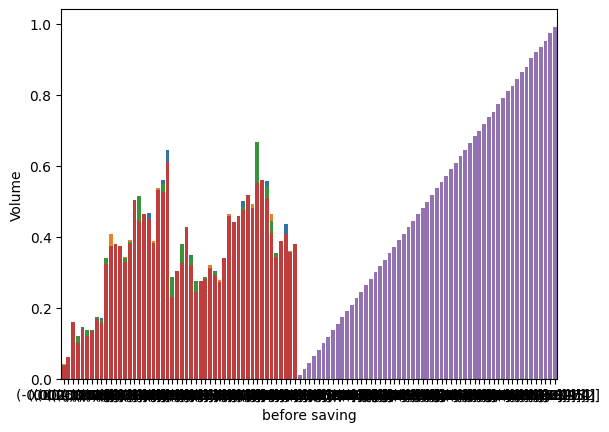

In [37]:
sns.barplot(x='Open_category', y='Volume', data=categorized_df, errorbar=None)
sns.barplot(x='Close_category', y='Volume', data=categorized_df, errorbar=None)
sns.barplot(x='Low_category', y='Volume', data=categorized_df, errorbar=None)
sns.barplot(x='High_category', y='Volume', data=categorized_df, errorbar=None)
sns.barplot(x='Volume_category', y='Volume', data=categorized_df, errorbar=None)

# plt.xlabel('categories: open, close, low, high, volume')
plt.xlabel('before saving')

In [38]:
categorized_df.to_csv('GLD_categorized_data.csv', index=False)

In [39]:
# Save the dataset with pickle
categorized_df.to_pickle("GLD_categorized_data.pkl")

In [40]:
file_path = "GLD_categorized_data.csv"

caized_df = pd.read_csv(file_path, delimiter=',')

In [41]:
print(categorized_df.dtypes)
print(caized_df.dtypes)


Date               datetime64[ns]
Open                      float64
High                      float64
Low                       float64
Close                     float64
Volume                    float64
Open_category            category
High_category            category
Low_category             category
Close_category           category
Volume_category          category
dtype: object
Date                object
Open               float64
High               float64
Low                float64
Close              float64
Volume             float64
Open_category       object
High_category       object
Low_category        object
Close_category      object
Volume_category     object
dtype: object


In [42]:
for col in ['Open_category', 'Close_category', 'Low_category', 'High_category', 'Volume_category']:
    caized_df[col] = caized_df[col].astype('category')

Text(0.5, 0, 'after saving')

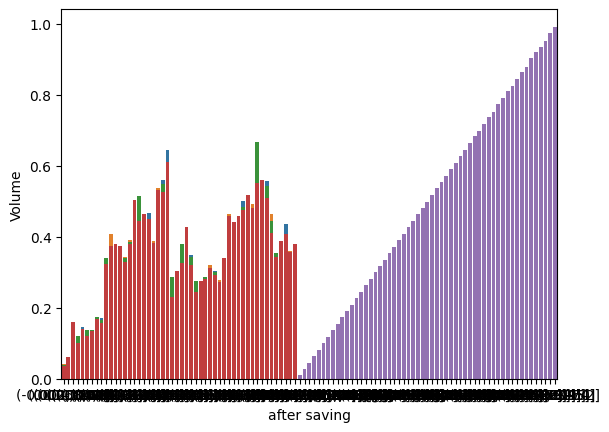

In [43]:
sns.barplot(x='Open_category', y='Volume', data=caized_df, errorbar=None)
sns.barplot(x='Close_category', y='Volume', data=caized_df, errorbar=None)
sns.barplot(x='Low_category', y='Volume', data=caized_df, errorbar=None)
sns.barplot(x='High_category', y='Volume', data=caized_df, errorbar=None)
sns.barplot(x='Volume_category', y='Volume', data=caized_df, errorbar=None)

# plt.xlabel('categories: open, close, low, high, volume')
plt.xlabel('after saving')

When categorized data is saved as a CSV file, the data types may be lost and converted to object, which can lead to inconsistencies in analysis and visualizations. To avoid this issue:

Convert the columns back to the category data type after reading the CSV file.
Use advanced formats like pickle or parquet for storage, as these formats preserve the original data types.